# Notebook 03 — Full Summary Statistics & Paper-Ready Tables

This notebook produces all numeric summaries cited in the paper text,
exports LaTeX-formatted table source, and generates a combined
overview figure suitable for inclusion in a slide deck.

Run after notebooks 00–02.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import wilcoxon

CSV_PATH    = '../results/benchmark_results.csv'
FIGURES_DIR = '../figures'
import os; os.makedirs(FIGURES_DIR, exist_ok=True)

df   = pd.read_csv(CSV_PATH)
cold = df[df['RunType'] == 'COLD'].copy()
warm = df[df['RunType'] == 'WARM'].copy()

FLAT_MODELS  = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7']
FLAT_QUERIES = ['Q1', 'Q2a', 'Q2b', 'Q2c', 'Q4', 'Q5', 'Q6', 'Q7']
print('Ready.')

Ready.


## 1  Complete statistics: median, std, min, max, IQR — flat series SF-10

In [2]:
sf10_flat = cold[
    (cold['SF'] == 10) &
    (cold['Model'].isin(FLAT_MODELS)) &
    (cold['Query'].isin(FLAT_QUERIES))
]

def full_stats(group):
    s = group['WallClock_ms']
    return pd.Series({
        'n':      len(s),
        'median': round(s.median(), 1),
        'std':    round(s.std(), 1),
        'min':    round(s.min(), 1),
        'max':    round(s.max(), 1),
        'IQR':    round(s.quantile(0.75) - s.quantile(0.25), 1),
        'CV_%':   round(s.std() / s.median() * 100, 1),
    })

stats_full = sf10_flat.groupby(['Model','Query']).apply(full_stats).reset_index()
print(stats_full.to_string(index=False))
stats_full.to_csv(f'{FIGURES_DIR}/full_stats_flat_sf10.csv', index=False)

Model Query    n   median     std      min      max     IQR  CV_%
   A1    Q1 20.0    732.1    35.1    689.7    810.6    31.0   4.8
   A1   Q2a 20.0    757.5   250.7    708.6   1872.5    51.0  33.1
   A1   Q2b 20.0    741.6    25.1    697.9    800.2    27.1   3.4
   A1   Q2c 20.0    759.2    18.4    734.7    805.8    18.6   2.4
   A1    Q4 20.0     76.4     4.0     71.2     88.4     4.1   5.3
   A1    Q5 20.0    942.5    24.5    894.9    984.5    30.5   2.6
   A1    Q6 20.0    883.6    20.2    850.6    929.2    18.0   2.3
   A1    Q7 20.0   1473.0    60.2   1414.4   1665.0    40.5   4.1
   A2    Q1 20.0    761.1    17.8    730.4    791.7    23.5   2.3
   A2   Q2a 20.0    764.0    17.0    735.6    792.4    27.3   2.2
   A2   Q2b 20.0    778.5    32.4    712.6    854.5    49.4   4.2
   A2   Q2c 20.0    771.5    20.9    739.3    820.6    30.3   2.7
   A2    Q4 20.0    256.8     5.5    246.5    264.7     6.4   2.1
   A2    Q5 20.0    973.6    24.5    940.4   1017.3    39.7   2.5
   A2    Q

C:\Users\davis\AppData\Local\Temp\ipykernel_32184\1646049998.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  stats_full = sf10_flat.groupby(['Model','Query']).apply(full_stats).reset_index()


## 2  Complete statistics — hierarchy B-series and C1, both SFs

In [3]:
hier_cold = cold[cold['Model'].isin(['B1','B2','B3','B4','C1'])]
hier_stats = hier_cold.groupby(['SF','Model','Query']).apply(full_stats).reset_index()
print(hier_stats.to_string(index=False))
hier_stats.to_csv(f'{FIGURES_DIR}/full_stats_hierarchy.csv', index=False)

 SF Model       Query    n  median   std    min    max   IQR  CV_%
  1    B1       Q3_B1 20.0    84.6   2.5   81.9   93.3   1.5   3.0
  1    B2       Q3_B2 20.0    71.4   2.0   68.7   76.6   2.4   2.8
  1    B3       Q3_B3 20.0    80.1   3.7   75.7   91.6   4.2   4.7
  1    B4   Q3_B4_day 20.0   912.0  63.8  811.6 1007.4  97.1   7.0
  1    B4 Q3_B4_month 20.0   990.3  68.0  930.2 1230.6  79.9   6.9
  1    C1     Q3_Both 20.0    69.8   3.0   66.9   77.6   3.7   4.3
  1    C1    Q3_Month 20.0    73.4   2.5   69.0   79.0   3.0   3.4
  1    C1     Q3_Year 20.0    72.5   3.5   70.0   85.0   3.1   4.8
 10    B1       Q3_B1 20.0   235.6  18.9  230.8  319.1   5.1   8.0
 10    B2       Q3_B2 20.0    88.4   2.8   85.6   96.2   1.8   3.1
 10    B3       Q3_B3 20.0    69.7   3.8   67.0   83.5   2.1   5.4
 10    B4   Q3_B4_day 20.0  5329.7 167.7 5017.4 5535.7 310.3   3.1
 10    B4 Q3_B4_month 20.0  5663.5 189.5 5273.5 6011.3 269.0   3.3
 10    C1     Q3_Both 20.0    70.9   1.7   68.4   74.4   2.8  

C:\Users\davis\AppData\Local\Temp\ipykernel_32184\2878980142.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hier_stats = hier_cold.groupby(['SF','Model','Query']).apply(full_stats).reset_index()


## 3  Key ratios cited in the paper

In [4]:
def med(sf, model, query):
    return cold[(cold['SF']==sf)&(cold['Model']==model)&(cold['Query']==query)]['WallClock_ms'].median()

print('=== Paper key ratios ===')
print()

# RQ1
a1_q1  = med(10,'A1','Q1');  a4_q1 = med(10,'A4','Q1');  a5_q1 = med(10,'A5','Q1')
a6_q1  = med(10,'A6','Q1');  a7_q1 = med(10,'A7','Q1')
a1_q4  = med(10,'A1','Q4');  a7_q4 = med(10,'A7','Q4')
print(f'A1→A4 Q1 spread:        {(a4_q1/a1_q1 - 1)*100:.0f}%  ({a1_q1:.0f} → {a4_q1:.0f} ms)')
print(f'A4→A5 cliff Q1:         {a5_q1/a4_q1:.2f}×  ({a4_q1:.0f} → {a5_q1:.0f} ms)')
print(f'A5→A6:                  {a6_q1/a5_q1:.1f}×')
print(f'A6→A7:                  {a7_q1/a6_q1:.1f}×')
print(f'A1→A7:                  {a7_q1/a1_q1:.0f}×')
print(f'Q4 A1→A7 metadata:      {a7_q4/a1_q4:.0f}×  ({a1_q4:.0f} → {a7_q4:.0f} ms)')
print()

# RQ2
b1 = med(10,'B1','Q3_B1'); b2 = med(10,'B2','Q3_B2')
b3 = med(10,'B3','Q3_B3'); b4m = med(10,'B4','Q3_B4_month'); b4d = med(10,'B4','Q3_B4_day')
print(f'B2 speedup vs B1:       {b1/b2:.2f}×')
print(f'B3 speedup vs B1:       {b1/b3:.2f}×')
print(f'B4 month slowdown vs B1:{b4m/b1:.1f}×')
print(f'B4 day   slowdown vs B1:{b4d/b1:.1f}×')
print(f'B4 month slowdown vs B3:{b4m/b3:.0f}×')
b1_sf1 = med(1,'B1','Q3_B1'); b3_sf1 = med(1,'B3','Q3_B3'); b4m_sf1 = med(1,'B4','Q3_B4_month')
print(f'SF-1: B3 speedup vs B1: {b1_sf1/b3_sf1:.2f}×')
print(f'SF-1: B4 slowdown vs B1:{b4m_sf1/b1_sf1:.1f}×')
print()

# RQ3
c1_m = med(10,'C1','Q3_Month'); c1_y = med(10,'C1','Q3_Year')
c1_b = med(10,'C1','Q3_Both');  b3_b = med(10,'B3','Q3_B3')
print(f'C1 nested vs top-level: {c1_y/c1_m:.2f}×  ({(c1_y/c1_m-1)*100:.0f}% penalty)')
print(f'C1(both) vs B3(both):   {c1_b/b3_b:.3f}×  ({(c1_b/b3_b-1)*100:.0f}% overhead)')
print()

# RQ4
for m in ['A1','A3','A4','A5','A6']:
    s1 = med(1,m,'Q1'); s10 = med(10,m,'Q1')
    print(f'Scalability {m}: SF-1={s1:.1f}  SF-10={s10:.1f}  ratio={s10/s1:.1f}×')

=== Paper key ratios ===

A1→A4 Q1 spread:        13%  (732 → 830 ms)
A4→A5 cliff Q1:         3.52×  (830 → 2919 ms)
A5→A6:                  9.7×
A6→A7:                  11.0×
A1→A7:                  428×
Q4 A1→A7 metadata:      2460×  (76 → 187858 ms)

B2 speedup vs B1:       2.66×
B3 speedup vs B1:       3.38×
B4 month slowdown vs B1:24.0×
B4 day   slowdown vs B1:22.6×
B4 month slowdown vs B3:81×
SF-1: B3 speedup vs B1: 1.06×
SF-1: B4 slowdown vs B1:11.7×

C1 nested vs top-level: 1.08×  (8% penalty)
C1(both) vs B3(both):   1.017×  (2% overhead)

Scalability A1: SF-1=112.8  SF-10=732.1  ratio=6.5×
Scalability A3: SF-1=106.2  SF-10=756.9  ratio=7.1×
Scalability A4: SF-1=110.2  SF-10=830.1  ratio=7.5×
Scalability A5: SF-1=112.3  SF-10=2919.4  ratio=26.0×
Scalability A6: SF-1=116.4  SF-10=28457.7  ratio=244.4×


## 4  Full Wilcoxon test matrix (all meaningful pairs)

In [9]:
def wrow(label, sf, model_a, q_a, model_b, q_b):
    a = cold[(cold['SF']==sf)&(cold['Model']==model_a)&(cold['Query']==q_a)]['WallClock_ms'].values
    b = cold[(cold['SF']==sf)&(cold['Model']==model_b)&(cold['Query']==q_b)]['WallClock_ms'].values
    stat, p = wilcoxon(a, b)
    return {
        'Comparison': label, 'SF': sf,
        'Median_A': round(np.median(a),1), 'Median_B': round(np.median(b),1),
        'W_statistic': stat, 'p_value': round(p, 8),
        'Significant': p < 0.05,
        'Sig_level': '***' if p<0.001 else ('**' if p<0.01 else ('*' if p<0.05 else 'ns'))
    }

tests = []
# Adjacent model pairs for Q1 SF-10
for m1, m2 in zip(FLAT_MODELS, FLAT_MODELS[1:]):
    tests.append(wrow(f'{m1} vs {m2} / Q1 / SF-10', 10, m1,'Q1', m2,'Q1'))

# A4 vs A5 for every query SF-10
for q in FLAT_QUERIES:
    tests.append(wrow(f'A4 vs A5 / {q} / SF-10', 10, 'A4',q, 'A5',q))

# Q2a vs Q2b vs Q2c within A1 SF-10 (selectivity insensitivity)
for q1, q2 in [('Q2a','Q2b'),('Q2a','Q2c'),('Q2b','Q2c')]:
    tests.append(wrow(f'A1 {q1} vs {q2} SF-10', 10, 'A1',q1, 'A1',q2))

# Hierarchy
for (ma,qa),(mb,qb),lbl in [
    (('B1','Q3_B1'),('B2','Q3_B2'),'B1 vs B2 SF-10'),
    (('B1','Q3_B1'),('B3','Q3_B3'),'B1 vs B3 SF-10'),
    (('B2','Q3_B2'),('B3','Q3_B3'),'B2 vs B3 SF-10'),
    (('B3','Q3_B3'),('B4','Q3_B4_month'),'B3 vs B4(month) SF-10'),
    (('B1','Q3_B1'),('B4','Q3_B4_month'),'B1 vs B4(month) SF-10'),
    (('B1','Q3_B1'),('B2','Q3_B2'),'B1 vs B2 SF-1'),   # SF-1
    (('B1','Q3_B1'),('B3','Q3_B3'),'B1 vs B3 SF-1'),
    (('B1','Q3_B1'),('B4','Q3_B4_month'),'B1 vs B4(month) SF-1'),
]:
    # FIX: Use endswith so 'SF-10' doesn't trigger 'SF-1'
    sf_val = 1 if lbl.endswith('SF-1') else 10
    
    # FIX: Pass ma, qa directly instead of ma[0], ma[1]
    tests.append(wrow(lbl, sf_val, ma, qa, mb, qb))

# Key ordering
for (ma,qa),(mb,qb),lbl in [
    (('C1','Q3_Month'),('C1','Q3_Year'),'C1: month vs year filter SF-10'),
    (('C1','Q3_Both'), ('B3','Q3_B3'), 'C1(both) vs B3(both) SF-10'),
]:
    # FIX: Pass ma, qa directly instead of ma[0], ma[1]
    tests.append(wrow(lbl, 10, ma, qa, mb, qb))

wdf = pd.DataFrame(tests)
print(wdf[['Comparison','SF','Median_A','Median_B','p_value','Sig_level']].to_string(index=False))
wdf.to_csv(f'{FIGURES_DIR}/wilcoxon_all_tests.csv', index=False)

                    Comparison  SF  Median_A  Median_B  p_value Sig_level
         A1 vs A2 / Q1 / SF-10  10     732.1     761.1 0.012079         *
         A2 vs A3 / Q1 / SF-10  10     761.1     756.9 0.701181        ns
         A3 vs A4 / Q1 / SF-10  10     756.9     830.1 0.000002       ***
         A4 vs A5 / Q1 / SF-10  10     830.1    2919.4 0.000002       ***
         A5 vs A6 / Q1 / SF-10  10    2919.4   28457.7 0.000002       ***
         A6 vs A7 / Q1 / SF-10  10   28457.7  313447.5 0.000002       ***
         A4 vs A5 / Q1 / SF-10  10     830.1    2919.4 0.000002       ***
        A4 vs A5 / Q2a / SF-10  10     845.0    3172.6 0.000002       ***
        A4 vs A5 / Q2b / SF-10  10     853.8    3201.6 0.000088       ***
        A4 vs A5 / Q2c / SF-10  10     850.8    3182.8 0.000002       ***
         A4 vs A5 / Q4 / SF-10  10     293.7    2004.9 0.000002       ***
         A4 vs A5 / Q5 / SF-10  10    1080.9    3980.3 0.000002       ***
         A4 vs A5 / Q6 / SF-10  10    

## 5  LaTeX table source — Table 1 (paper)

In [10]:
sf10_flat = cold[
    (cold['SF'] == 10) &
    (cold['Model'].isin(FLAT_MODELS)) &
    (cold['Query'].isin(FLAT_QUERIES))
]
pivot = (
    sf10_flat.groupby(['Model','Query'])['WallClock_ms']
    .median().unstack()[FLAT_QUERIES].reindex(FLAT_MODELS)
)

MODEL_CONFIG = {
    'A1': r'$1\times7.5$\,GB',
    'A2': r'$8\times950$\,MB',
    'A3': r'$38\times200$\,MB',
    'A4': r'$75\times100$\,MB',
    'A5': r'$150\times50$\,MB',
    'A6': r'$750\times10$\,MB',
    'A7': r'$7500\times1$\,MB',
}

def fmt_ms(v):
    v = round(v)
    if v >= 1000:
        return rf'{v:,}'.replace(',', r'\,')
    return str(v)

lines = []
for model in FLAT_MODELS:
    vals = [fmt_ms(pivot.loc[model, q]) for q in FLAT_QUERIES]
    lines.append(f'{model} & {MODEL_CONFIG[model]} & ' + ' & '.join(vals) + r' \\')

latex_table = '\n'.join(lines)
print(latex_table)

with open(f'{FIGURES_DIR}/table1_latex_rows.tex', 'w') as f:
    f.write(latex_table)
print('\nSaved table1_latex_rows.tex')

A1 & $1\times7.5$\,GB & 732 & 757 & 742 & 759 & 76 & 943 & 884 & 1\,473 \\
A2 & $8\times950$\,MB & 761 & 764 & 778 & 772 & 257 & 974 & 1\,001 & 1\,525 \\
A3 & $38\times200$\,MB & 757 & 763 & 783 & 815 & 274 & 1\,068 & 1\,071 & 1\,661 \\
A4 & $75\times100$\,MB & 830 & 845 & 854 & 851 & 294 & 1\,081 & 1\,070 & 1\,701 \\
A5 & $150\times50$\,MB & 2\,919 & 3\,173 & 3\,202 & 3\,183 & 2\,005 & 3\,980 & 3\,738 & 4\,608 \\
A6 & $750\times10$\,MB & 28\,458 & 29\,055 & 29\,325 & 29\,322 & 23\,450 & 30\,050 & 26\,726 & 28\,803 \\
A7 & $7500\times1$\,MB & 313\,448 & 303\,301 & 335\,685 & 347\,109 & 187\,858 & 336\,900 & 296\,805 & 254\,750 \\

Saved table1_latex_rows.tex


## 6  Combined overview figure — 4-panel summary

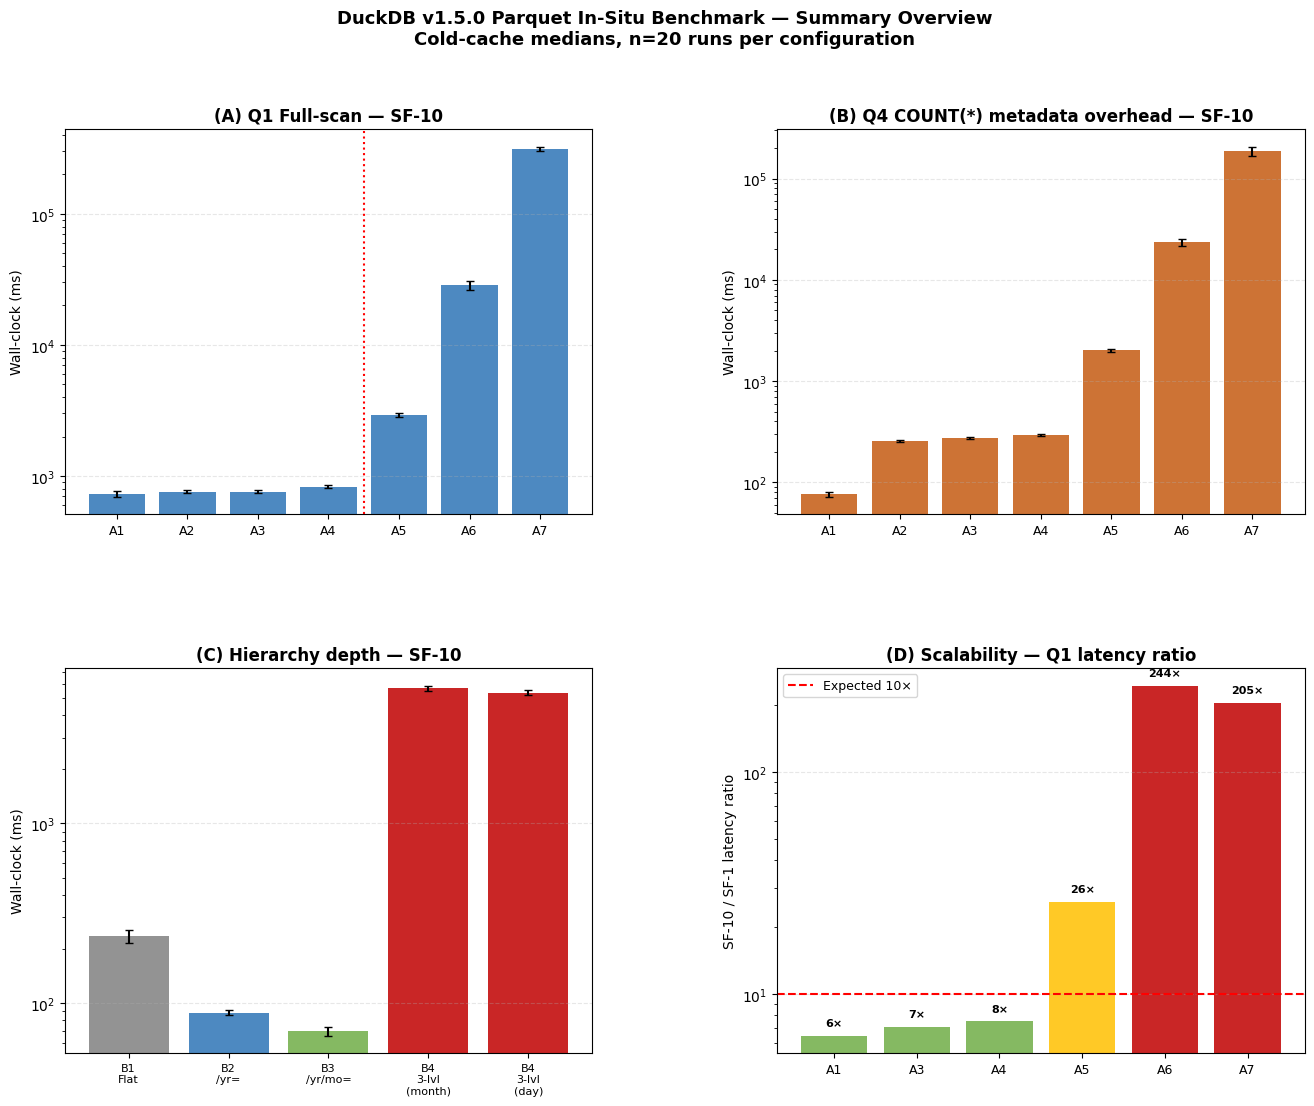

Saved fig_summary_overview


In [11]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# ── Panel A: Q1 wall-clock vs model, SF-10 ──────────────────────────────
ax_a = fig.add_subplot(gs[0, 0])
models_sf10 = FLAT_MODELS
sub_q1 = cold[(cold['SF']==10)&(cold['Query']=='Q1')&(cold['Model'].isin(models_sf10))]
meds = sub_q1.groupby('Model')['WallClock_ms'].median().reindex(models_sf10)
stds = sub_q1.groupby('Model')['WallClock_ms'].std().reindex(models_sf10)
ax_a.bar(range(len(models_sf10)), meds, yerr=stds, capsize=3,
         color='#2E75B6', alpha=0.85)
ax_a.axvline(3.5, color='red', linestyle=':', linewidth=1.5)
ax_a.set_yscale('log')
ax_a.set_xticks(range(len(models_sf10)))
ax_a.set_xticklabels(models_sf10, fontsize=9)
ax_a.set_ylabel('Wall-clock (ms)')
ax_a.set_title('(A) Q1 Full-scan — SF-10', fontweight='bold')
ax_a.grid(axis='y', linestyle='--', alpha=0.3)

# ── Panel B: Q4 metadata, SF-10 ─────────────────────────────────────────
ax_b = fig.add_subplot(gs[0, 1])
sub_q4 = cold[(cold['SF']==10)&(cold['Query']=='Q4')&(cold['Model'].isin(models_sf10))]
meds4 = sub_q4.groupby('Model')['WallClock_ms'].median().reindex(models_sf10)
stds4 = sub_q4.groupby('Model')['WallClock_ms'].std().reindex(models_sf10)
ax_b.bar(range(len(models_sf10)), meds4, yerr=stds4, capsize=3,
         color='#C55A11', alpha=0.85)
ax_b.set_yscale('log')
ax_b.set_xticks(range(len(models_sf10)))
ax_b.set_xticklabels(models_sf10, fontsize=9)
ax_b.set_ylabel('Wall-clock (ms)')
ax_b.set_title('(B) Q4 COUNT(*) metadata overhead — SF-10', fontweight='bold')
ax_b.grid(axis='y', linestyle='--', alpha=0.3)

# ── Panel C: Hierarchy depth B1–B4, SF-10 ───────────────────────────────
ax_c = fig.add_subplot(gs[1, 0])
hier_models = [('B1','Q3_B1'),('B2','Q3_B2'),('B3','Q3_B3'),('B4','Q3_B4_month'),('B4','Q3_B4_day')]
hlabels = ['B1\nFlat','B2\n/yr=','B3\n/yr/mo=','B4\n3-lvl\n(month)','B4\n3-lvl\n(day)']
hcolors = ['#808080','#2E75B6','#70AD47','#C00000','#C00000']
hmeds = [cold[(cold['SF']==10)&(cold['Model']==m)&(cold['Query']==q)]['WallClock_ms'].median()
         for m,q in hier_models]
hstds = [cold[(cold['SF']==10)&(cold['Model']==m)&(cold['Query']==q)]['WallClock_ms'].std()
         for m,q in hier_models]
ax_c.bar(range(len(hlabels)), hmeds, yerr=hstds, capsize=3, color=hcolors, alpha=0.85)
ax_c.set_yscale('log')
ax_c.set_xticks(range(len(hlabels)))
ax_c.set_xticklabels(hlabels, fontsize=8)
ax_c.set_ylabel('Wall-clock (ms)')
ax_c.set_title('(C) Hierarchy depth — SF-10', fontweight='bold')
ax_c.grid(axis='y', linestyle='--', alpha=0.3)

# ── Panel D: Scalability ratio ───────────────────────────────────────────
ax_d = fig.add_subplot(gs[1, 1])
sc_models = ['A1','A3','A4','A5','A6','A7']
sc_ratios = []
for m in sc_models:
    s1  = cold[(cold['SF']==1) &(cold['Model']==m)&(cold['Query']=='Q1')]['WallClock_ms'].median()
    s10 = cold[(cold['SF']==10)&(cold['Model']==m)&(cold['Query']=='Q1')]['WallClock_ms'].median()
    sc_ratios.append(s10/s1)
sc_colors = ['#70AD47' if r < 12 else '#FFC000' if r < 50 else '#C00000' for r in sc_ratios]
ax_d.bar(range(len(sc_models)), sc_ratios, color=sc_colors, alpha=0.85)
ax_d.axhline(10, color='red', linestyle='--', linewidth=1.5, label='Expected 10×')
ax_d.set_xticks(range(len(sc_models)))
ax_d.set_xticklabels(sc_models, fontsize=9)
ax_d.set_yscale('log')
ax_d.set_ylabel('SF-10 / SF-1 latency ratio')
ax_d.set_title('(D) Scalability — Q1 latency ratio', fontweight='bold')
ax_d.legend(fontsize=9)
ax_d.grid(axis='y', linestyle='--', alpha=0.3)
for i, (m, r) in enumerate(zip(sc_models, sc_ratios)):
    ax_d.text(i, r*1.1, f'{r:.0f}×', ha='center', fontsize=8, fontweight='bold')

fig.suptitle('DuckDB v1.5.0 Parquet In-Situ Benchmark — Summary Overview\n'
             'Cold-cache medians, n=20 runs per configuration',
             fontsize=13, fontweight='bold')
plt.savefig(f'{FIGURES_DIR}/fig_summary_overview.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES_DIR}/fig_summary_overview.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved fig_summary_overview')

## 7  Export all tables to Excel workbook

In [13]:
with pd.ExcelWriter(f'{FIGURES_DIR}/all_benchmark_tables.xlsx', engine='openpyxl') as writer:

    # Sheet 1 — cold medians pivot, SF-10
    pivot_out = (
        sf10_flat.groupby(['Model','Query'])['WallClock_ms']
        .median().unstack()[FLAT_QUERIES].reindex(FLAT_MODELS).round(1)
    )
    pivot_out.to_excel(writer, sheet_name='Table1_Medians_SF10')

    # Sheet 2 — cold std pivot, SF-10
    pivot_std = (
        sf10_flat.groupby(['Model','Query'])['WallClock_ms']
        .std().unstack()[FLAT_QUERIES].reindex(FLAT_MODELS).round(1)
    )
    pivot_std.to_excel(writer, sheet_name='Table1_StdDev_SF10')

    # Sheet 3 — full stats
    stats_full.to_excel(writer, sheet_name='FullStats_Flat_SF10', index=False)

    # Sheet 4 — hierarchy
    hier_stats.to_excel(writer, sheet_name='HierarchyStats', index=False)

    # Sheet 5 — Wilcoxon tests
    wdf.to_excel(writer, sheet_name='WilcoxonTests', index=False)

    # Sheet 6 — scalability table
    sc_rows = []
    for m in ['A1','A3','A4','A5','A6','A7']:
        sf1_rows  = cold[(cold['SF']==1) &(cold['Model']==m)&(cold['Query']=='Q1')]
        sf10_rows = cold[(cold['SF']==10)&(cold['Model']==m)&(cold['Query']=='Q1')]
        if sf1_rows.empty: continue
        sc_rows.append({
            'Model': m,
            'SF-1 Median (ms)':  round(sf1_rows['WallClock_ms'].median(), 1),
            'SF-10 Median (ms)': round(sf10_rows['WallClock_ms'].median(), 1),
            'Ratio':             round(sf10_rows['WallClock_ms'].median() / sf1_rows['WallClock_ms'].median(), 1),
        })
    pd.DataFrame(sc_rows).to_excel(writer, sheet_name='Scalability_Q1', index=False)

    # Sheet 7 — RAM
    ram_out = (
        cold[(cold['SF']==10)&(cold['Query'].isin(['Q1','Q7']))&(cold['Model'].isin(FLAT_MODELS))]
        .groupby(['Model','Query'])['PeakRAM_KB']
        .median().unstack().reindex(FLAT_MODELS).div(1024).round(0)
    )
    ram_out.columns = [f'{c} peak RAM (MB)' for c in ram_out.columns]
    ram_out.to_excel(writer, sheet_name='PeakRAM_SF10')

print('Saved all_benchmark_tables.xlsx')

Saved all_benchmark_tables.xlsx
